# Classroom Reaction Recognition

**ResNet18 vs VGG16 Transfer Learning Comparison**

This notebook trains and evaluates two CNN architectures on a 5-class facial reaction dataset:
- **Neutral** -- no visible expression
- **Confused** -- furrowed brow, squinting
- **Smiling_Amused** -- visible smile, laughter
- **Surprised** -- raised eyebrows, open mouth
- **Bored_Tired** -- yawning, blank stare

Dataset was extracted from classroom lecture videos using YOLOv8 person detection and split 70/10/20.

## 1. Environment Setup

In [ ]:
pip install -q torch torchvision scikit-learn matplotlib seaborn pandas tqdm pyyaml

In [12]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Mount Google Drive & Load Dataset

Upload `reaction_dataset.zip` to your Google Drive root or a folder, then update the path below.

In [21]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/content/data/crops")
DRIVE_ZIP = Path("/content/drive/MyDrive/reaction_dataset.zip")

import shutil

shutil.rmtree("/content/data", ignore_errors=True)

print("Extracting with path fix...")
with zipfile.ZipFile(str(DRIVE_ZIP), "r") as z:
    for info in z.infolist():
        fixed = info.filename.replace("\\", "/")
        target = DATA_DIR / fixed
        if info.is_dir():
            target.mkdir(parents=True, exist_ok=True)
        else:
            target.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(target, "wb") as dst:
                dst.write(src.read())
print("Done.")

for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    if split_dir.exists():
        classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        counts = {c: len(list((split_dir / c).glob("*.jpg"))) for c in classes}
        print(f"{split:>5}: {sum(counts.values()):>4} images  {counts}")
    else:
        print(f"{split:>5}: MISSING!")

Extracting with path fix...
Done.
train:  545 images  {'Bored_Tired': 14, 'Confused': 18, 'Neutral': 349, 'Smiling_Amused': 157, 'Surprised': 7}
  val:   78 images  {'Bored_Tired': 2, 'Confused': 2, 'Neutral': 50, 'Smiling_Amused': 23, 'Surprised': 1}
 test:  157 images  {'Bored_Tired': 4, 'Confused': 5, 'Neutral': 101, 'Smiling_Amused': 45, 'Surprised': 2}


## 3. Configuration & Data Loading

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

SEED = 42
torch.manual_seed(SEED)

CLASS_NAMES = ["Bored_Tired", "Confused", "Neutral", "Smiling_Amused", "Surprised"]
NUM_CLASSES = len(CLASS_NAMES)
INPUT_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [27]:
train_tf = transforms.Compose(
    [
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)
val_tf = transforms.Compose(
    [
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_dataset = datasets.ImageFolder(str(DATA_DIR / "train"), transform=train_tf)
val_dataset = datasets.ImageFolder(str(DATA_DIR / "val"), transform=val_tf)
test_dataset = datasets.ImageFolder(str(DATA_DIR / "test"), transform=val_tf)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(
    f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}"
)
print(f"Classes (ImageFolder order): {train_dataset.classes}")

Train: 545  Val: 78  Test: 157
Classes (ImageFolder order): ['Bored_Tired', 'Confused', 'Neutral', 'Smiling_Amused', 'Surprised']


In [28]:
counts = Counter(train_dataset.targets)
total = len(train_dataset.targets)
num_c = len(counts)
class_weights = torch.FloatTensor(
    [total / (num_c * counts[i]) for i in range(num_c)]
).to(device)

print("Class counts :", dict(counts))
print("Class weights:", [round(w.item(), 3) for w in class_weights])

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class counts : {0: 14, 1: 18, 2: 349, 3: 157, 4: 7}
Class weights: [7.786, 6.056, 0.312, 0.694, 15.571]


## 4. Model Definitions

In [29]:
def build_resnet18(num_classes, device):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def build_vgg16(num_classes, device):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model.to(device)

## 5. Training Loop

In [30]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def train_model(name, model, train_loader, val_loader, criterion, device, lr, epochs):
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    best_val_acc = 0.0
    best_weights = None
    history = []

    print(f"\n{'=' * 60}")
    print(f"Training {name} for {epochs} epochs")
    print(f"{'=' * 60}\n")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        tag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            tag = "  <-- best"

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}{tag}"
        )
        history.append([epoch, train_loss, train_acc, val_loss, val_acc])

    print(f"\n{name} complete. Best Val Accuracy: {best_val_acc:.3f}")
    return best_weights, history

## 6. Train ResNet18

In [31]:
resnet = build_resnet18(NUM_CLASSES, device)
resnet_weights, resnet_history = train_model(
    "ResNet18", resnet, train_loader, val_loader, criterion, device, LR, EPOCHS
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]



Training ResNet18 for 15 epochs

Epoch 01/15 | Train Loss: 1.7701  Acc: 0.185 | Val Loss: 1.6652  Acc: 0.282  <-- best
Epoch 02/15 | Train Loss: 1.5051  Acc: 0.367 | Val Loss: 1.6992  Acc: 0.218
Epoch 03/15 | Train Loss: 1.3764  Acc: 0.382 | Val Loss: 1.6259  Acc: 0.513  <-- best
Epoch 04/15 | Train Loss: 1.2668  Acc: 0.499 | Val Loss: 1.6388  Acc: 0.256
Epoch 05/15 | Train Loss: 1.2358  Acc: 0.585 | Val Loss: 1.5827  Acc: 0.462
Epoch 06/15 | Train Loss: 1.1121  Acc: 0.651 | Val Loss: 1.6136  Acc: 0.577  <-- best
Epoch 07/15 | Train Loss: 1.0729  Acc: 0.628 | Val Loss: 1.5871  Acc: 0.513
Epoch 08/15 | Train Loss: 0.9955  Acc: 0.679 | Val Loss: 1.6457  Acc: 0.590  <-- best
Epoch 09/15 | Train Loss: 0.9918  Acc: 0.681 | Val Loss: 1.6279  Acc: 0.526
Epoch 10/15 | Train Loss: 0.8976  Acc: 0.547 | Val Loss: 1.7720  Acc: 0.603  <-- best
Epoch 11/15 | Train Loss: 0.8637  Acc: 0.666 | Val Loss: 1.7161  Acc: 0.449
Epoch 12/15 | Train Loss: 0.9276  Acc: 0.598 | Val Loss: 1.7789  Acc: 0.603
Epoc

## 7. Train VGG16

In [32]:
vgg = build_vgg16(NUM_CLASSES, device)
vgg_weights, vgg_history = train_model(
    "VGG16", vgg, train_loader, val_loader, criterion, device, LR, EPOCHS
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 79.7MB/s]



Training VGG16 for 15 epochs

Epoch 01/15 | Train Loss: 2.5546  Acc: 0.484 | Val Loss: 3.1080  Acc: 0.769  <-- best
Epoch 02/15 | Train Loss: 2.9632  Acc: 0.578 | Val Loss: 4.6843  Acc: 0.564
Epoch 03/15 | Train Loss: 2.8762  Acc: 0.628 | Val Loss: 6.9442  Acc: 0.654
Epoch 04/15 | Train Loss: 2.8682  Acc: 0.717 | Val Loss: 8.9201  Acc: 0.654
Epoch 05/15 | Train Loss: 3.3743  Acc: 0.772 | Val Loss: 11.4853  Acc: 0.654
Epoch 06/15 | Train Loss: 3.3310  Acc: 0.771 | Val Loss: 15.9696  Acc: 0.705
Epoch 07/15 | Train Loss: 5.2300  Acc: 0.771 | Val Loss: 13.8979  Acc: 0.756
Epoch 08/15 | Train Loss: 5.0359  Acc: 0.782 | Val Loss: 16.5419  Acc: 0.628
Epoch 09/15 | Train Loss: 3.9038  Acc: 0.767 | Val Loss: 22.1495  Acc: 0.744
Epoch 10/15 | Train Loss: 7.4988  Acc: 0.760 | Val Loss: 37.0505  Acc: 0.756
Epoch 11/15 | Train Loss: 12.5638  Acc: 0.738 | Val Loss: 36.9587  Acc: 0.769
Epoch 12/15 | Train Loss: 9.3874  Acc: 0.822 | Val Loss: 46.4323  Acc: 0.744
Epoch 13/15 | Train Loss: 6.2138  Acc:

## 8. Training Curves -- ResNet18 vs VGG16

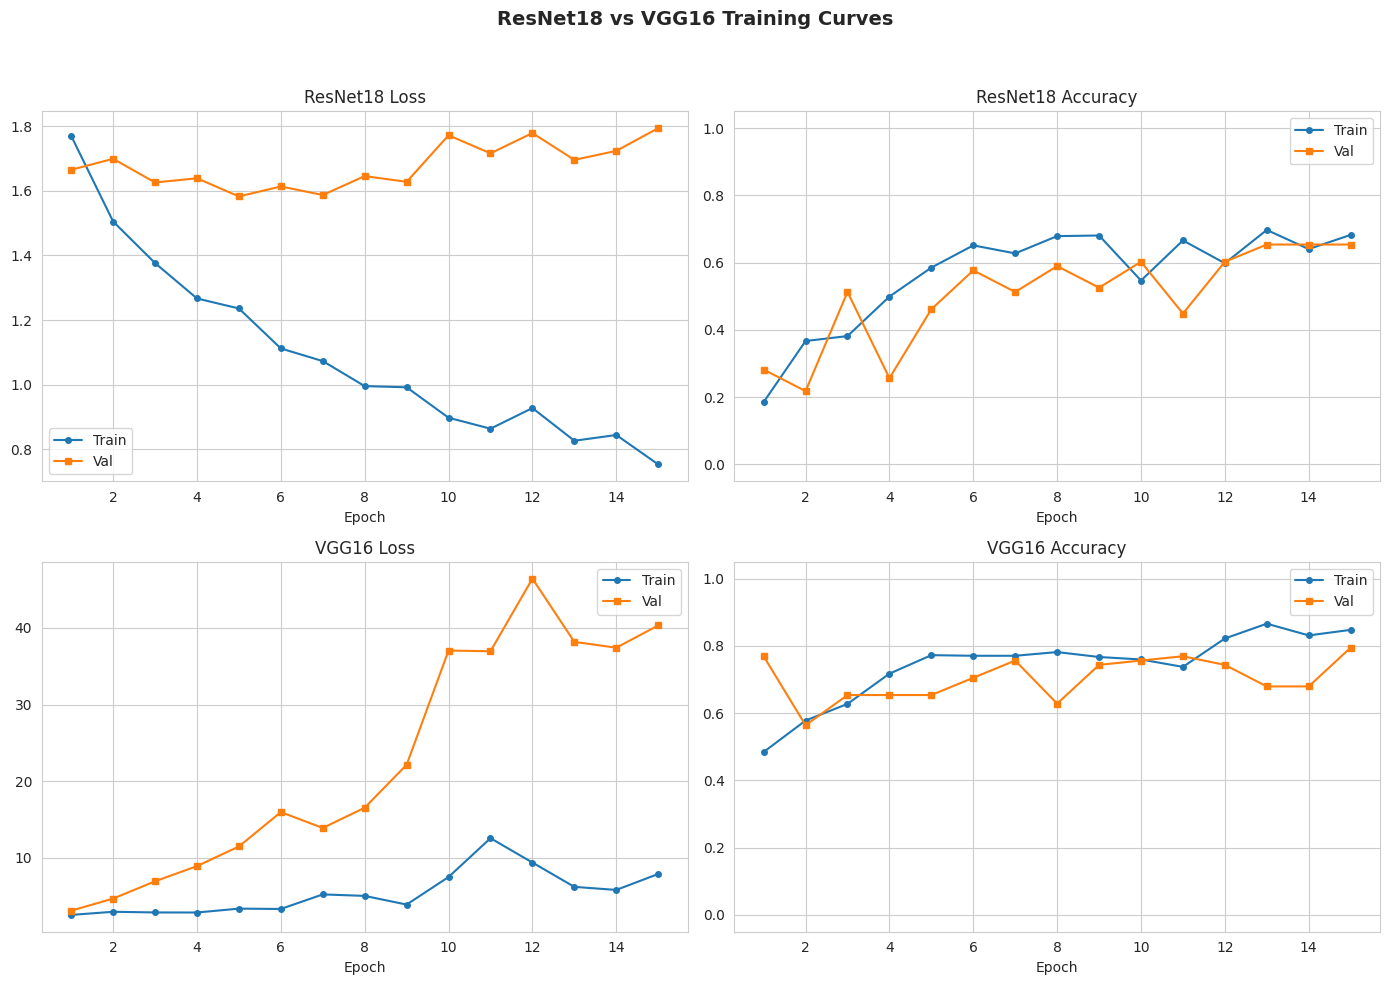

In [33]:
def plot_history(history, name, axes_row):
    epochs_col = [h[0] for h in history]
    ax_loss, ax_acc = axes_row
    ax_loss.plot(epochs_col, [h[1] for h in history], "o-", ms=4, label="Train")
    ax_loss.plot(epochs_col, [h[3] for h in history], "s-", ms=4, label="Val")
    ax_loss.set_title(f"{name} Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend()
    ax_acc.plot(epochs_col, [h[2] for h in history], "o-", ms=4, label="Train")
    ax_acc.plot(epochs_col, [h[4] for h in history], "s-", ms=4, label="Val")
    ax_acc.set_title(f"{name} Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylim(-0.05, 1.05)
    ax_acc.legend()


sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_history(resnet_history, "ResNet18", axes[0])
plot_history(vgg_history, "VGG16", axes[1])
fig.suptitle("ResNet18 vs VGG16 Training Curves", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 9. Evaluation on Test Set

In [34]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_true, all_pred = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds.cpu().numpy())
    return np.array(all_true), np.array(all_pred)


def evaluate_and_plot(model, weights, name, loader, class_names, device):
    model.load_state_dict({k: v.to(device) for k, v in weights.items()})
    y_true, y_pred = collect_predictions(model, loader, device)

    print(f"\n{'=' * 60}")
    print(f"{name} -- Test Set Evaluation")
    print(f"{'=' * 60}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }


ResNet18 -- Test Set Evaluation
                precision    recall  f1-score   support

   Bored_Tired       0.00      0.00      0.00         4
      Confused       0.15      0.40      0.22         5
       Neutral       0.86      0.73      0.79       101
Smiling_Amused       0.68      0.62      0.65        45
     Surprised       0.00      0.00      0.00         2

      accuracy                           0.66       157
     macro avg       0.34      0.35      0.33       157
  weighted avg       0.75      0.66      0.70       157



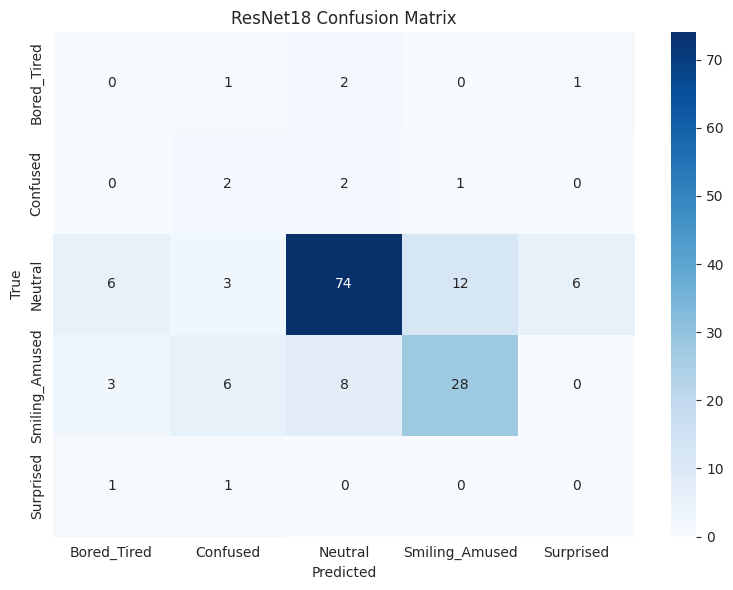

In [35]:
resnet_eval = build_resnet18(NUM_CLASSES, device)
r_metrics = evaluate_and_plot(
    resnet_eval, resnet_weights, "ResNet18", test_loader, CLASS_NAMES, device
)


VGG16 -- Test Set Evaluation
                precision    recall  f1-score   support

   Bored_Tired       0.00      0.00      0.00         4
      Confused       0.20      0.20      0.20         5
       Neutral       0.81      0.91      0.86       101
Smiling_Amused       0.75      0.60      0.67        45
     Surprised       0.00      0.00      0.00         2

      accuracy                           0.76       157
     macro avg       0.35      0.34      0.35       157
  weighted avg       0.75      0.76      0.75       157



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


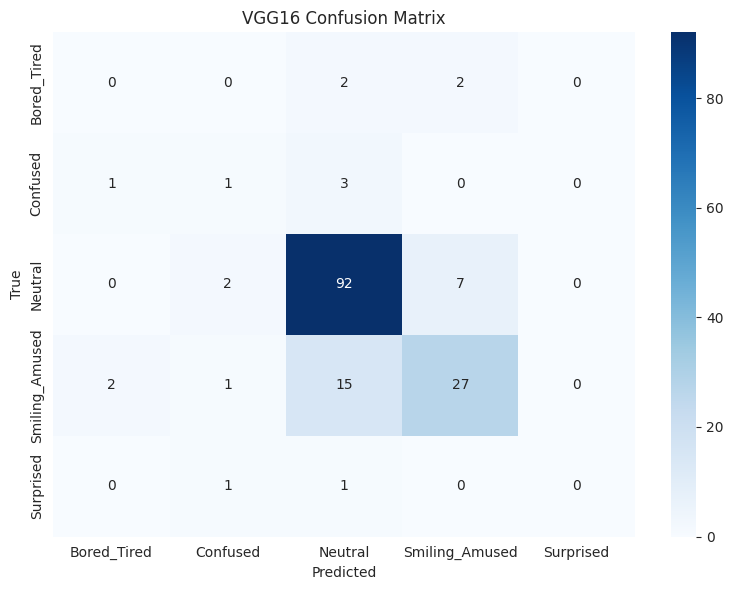

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
vgg_eval = build_vgg16(NUM_CLASSES, device)
v_metrics = evaluate_and_plot(
    vgg_eval, vgg_weights, "VGG16", test_loader, CLASS_NAMES, device
)

## 10. Side-by-Side Model Comparison

          accuracy  precision  recall     f1
model                                       
ResNet18    0.6624     0.7542  0.6624 0.7029
VGG16       0.7643     0.7451  0.7643 0.7506



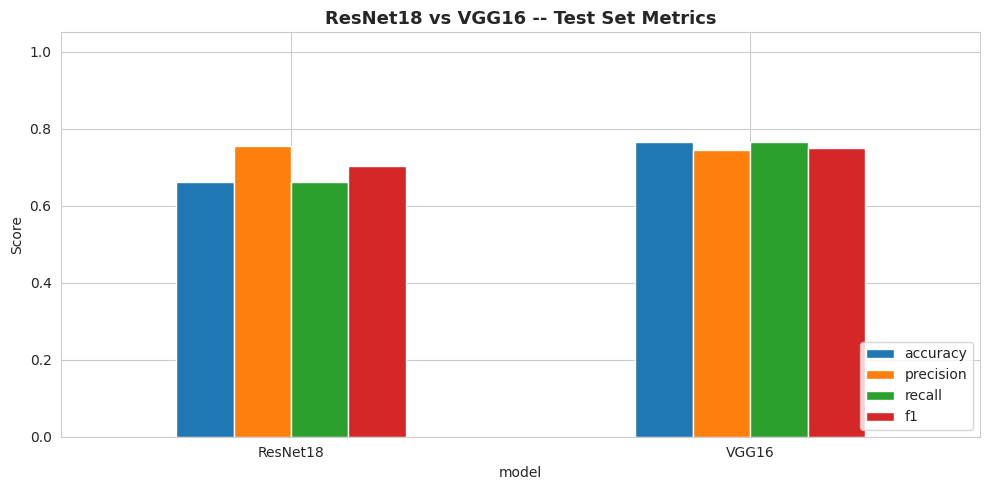

In [39]:
import pandas as pd

comparison = pd.DataFrame([r_metrics, v_metrics])
comparison = comparison.set_index("model")
print(comparison.to_string(float_format="{:.4f}".format))
print()

comparison.plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05), rot=0)
plt.title("ResNet18 vs VGG16 -- Test Set Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Save Weights to Google Drive

In [40]:
save_dir = Path("/content/drive/MyDrive/Reaction_Results")
save_dir.mkdir(parents=True, exist_ok=True)

torch.save(resnet_weights, str(save_dir / "best_resnet18.pth"))
torch.save(vgg_weights, str(save_dir / "best_vgg16.pth"))

comparison.to_csv(str(save_dir / "model_comparison.csv"))

print(f"Weights and comparison saved to {save_dir}")

Weights and comparison saved to /content/drive/MyDrive/Reaction_Results
